In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [106]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Decision Tree

### Cell 1: 라이브러리 및 데이터 로드

In [111]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()
# ---------------------------------------------------------
# [추가됨] 2.5 도메인 지식 기반 파생 변수 (Feature Engineering)
# 로봇이 멈춰있는 상태(Speed=0)를 트리가 명시적으로 알 수 있도록 이진 변수 추가
# 미세한 센서 노이즈를 고려하여, 6개 관절 속도 절대값의 합이 0.05 미만이면 정지(1)로 간주
# ---------------------------------------------------------
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)
# 3. 입력 피처(X) 및 타겟(y) 설정 (파생 변수 포함)
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'  # 새롭게 만든 파생 변수를 학습 피처로 추가
]
X = df_clean[input_cols]
y = df_clean['Tool_current']
print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개, 타겟: Tool_current")

데이터 크기: (7355, 25)
피처 개수: 13개, 타겟: Tool_current


### Cell 2: Train/Test Split (교차 검증을 위한 준비)

In [112]:
# 1. 80:20으로 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 결정 트리(Tree 기반 모델)는 거리 기반 알고리즘이 아니므로 
# StandardScaler나 MinMaxScaler와 같은 스케일링이 필수는 아닙니다.
# 따라서 스케일링 단계는 생략하고 원본 데이터를 그대로 사용합니다.

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (5884, 13)
테스트 데이터 크기: (1471, 13)


### Cell 3: Decision Tree 모델 K-Fold 교차검증 및 하이퍼파라미터 튜닝

In [113]:
# 1. 교차 검증 (K-Fold) 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Decision Tree Regressor 기본 모델 생성
dt_reg = DecisionTreeRegressor(random_state=42)

# 3. 튜닝할 하이퍼파라미터 그리드 설정
# - max_depth: 트리의 최대 깊이 (과적합 방지)
# - min_samples_split: 노드를 분할하기 위한 최소 샘플 수
# - min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 수
param_grid = {
    #'max_depth': [None, 5, 10, 15, 20],
    #'min_samples_split': [2, 10, 20],
    #'min_samples_leaf': [1, 5, 10]
    #'max_depth' : [4, 5, 6, 7, 8, 9, 10],       # 오버피팅을 막기 위해 나무 깊이를 적절히 제한
    #'min_samples_split': [4, 6, 7, 8, 10],
    #'min_samples_split': [10, 20, 30], 
    #'min_samples_leaf': [4, 5, 6, 7, 8],     # 리프 노드의 최소 샘플 수를 키워 규제 적용
    #'min_samples_leaf': [5, 10, 15, 20] 
    'max_depth': [5, 6, 7, 8],
    'min_samples_leaf': [7, 10, 15, 20, 30],  # 리프 노드 제한 범위를 더 넓혀봄
    'min_samples_split': [10, 20, 25, 30]
}

# 4. GridSearchCV 실행 (R² 기준으로 최적 파라미터 탐색)
print("--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=dt_reg, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 5. 최적 모델 및 결과 확인
best_dt = grid_search.best_estimator_

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 R² 점수: {grid_search.best_score_:.4f}")

--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 80 candidates, totalling 400 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • max_depth: 8
  • min_samples_leaf: 7
  • min_samples_split: 20

최고 교차 검증 R² 점수: 0.4256


### Cell 4: 최종 테스트 데이터 평가

In [116]:
# 1. GridSearchCV 결과에서 상위 5개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_r2 = row['mean_test_score']
    
    # 해당 파라미터로 모델 재학습
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 평가지표 계산
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환 (예: D=7, L=7, S=20)
    # D: max_depth, L: min_samples_leaf, S: min_samples_split
    depth = params.get('max_depth', 'None')
    leaf = params.get('min_samples_leaf', '-')
    split = params.get('min_samples_split', '-')
    param_short = f"D={depth}, L={leaf}, S={split}"
    
    # 결과 저장 (과적합 정도를 보기 위해 Gap 추가)
    comparison_data.append({
        '순위': rank,
        'CV R²': round(cv_r2, 4),
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        '과적합 Gap': round(train_r2 - test_r2, 4), # Train과 Test의 차이
        'Train MSE': round(mean_squared_error(y_train, y_train_pred), 6),
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (가독성 향상)
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df) # Jupyter Notebook 환경에서는 표 형태로 예쁘게 출력됩니다. (터미널이면 print(comparison_df) 사용)


print("\n" + "="*50)
print("--- [상세 분석] 1위 최적 모델 최종 평가지표 ---")
print("="*50)

# (기존 작성하신 코드 유지 - 1위 모델 상세 지표 출력)
best_dt = grid_search.best_estimator_
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)

def print_metrics(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print_metrics(y_train, y_train_pred_best, "Train")
print_metrics(y_test, y_test_pred_best, "Test")

--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---


,순위,CV R²,Train R²,Test R²,과적합 Gap,Train MSE,Test MSE,파라미터 설정
0,1,0.4256,0.6253,0.4442,0.1810,0.002395,0.003052,"D=8, L=7, S=20"
1,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=25"
2,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=20"
3,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=10"
4,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=30"
5,6,0.4169,0.6397,0.4697,0.1700,0.002303,0.002912,"D=8, L=7, S=10"
6,7,0.4168,0.5990,0.4201,0.1789,0.002563,0.003185,"D=7, L=7, S=20"
7,8,0.4164,0.5567,0.4273,0.1294,0.002833,0.003145,"D=6, L=7, S=20"
8,9,0.4150,0.5586,0.4342,0.1244,0.002821,0.003108,"D=6, L=7, S=10"
9,10,0.4149,0.6089,0.4391,0.1698,0.002500,0.003081,"D=7, L=7, S=10"



--- [상세 분석] 1위 최적 모델 최종 평가지표 ---

[Train 데이터 평가]
R² (결정계수) : 0.6253
MSE  : 0.002395
RMSE : 0.048939
MAE  : 0.018936

[Test 데이터 평가]
R² (결정계수) : 0.4442
MSE  : 0.003052
RMSE : 0.055246
MAE  : 0.021223


### Cell 5: 피처 중요도 (Feature Importance) 및 시각화

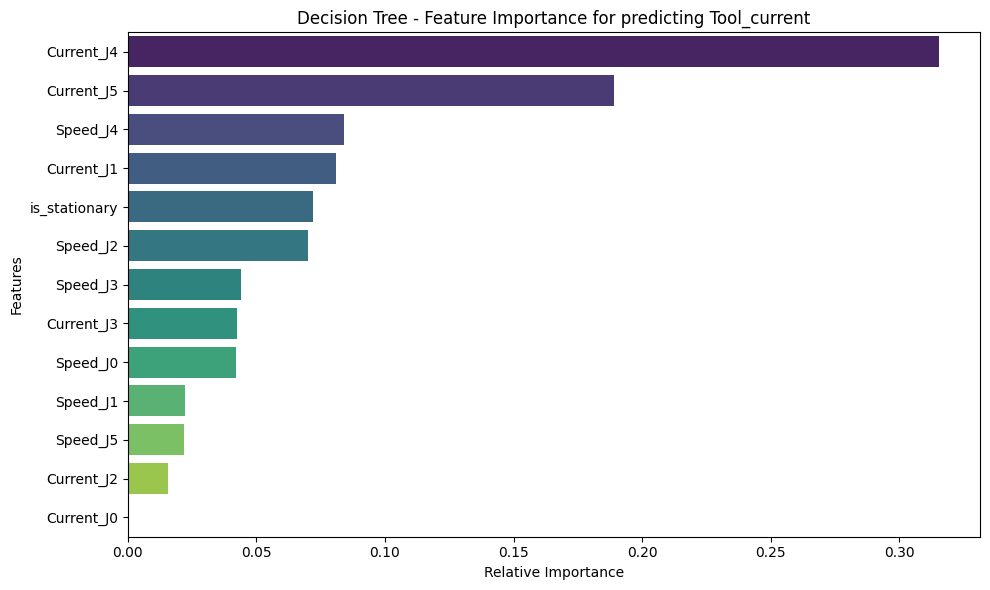

가장 중요한 피처 상위 3개:
   Feature  Importance
Current_J4    0.315619
Current_J5    0.189089
  Speed_J4    0.084076


In [117]:
# 1. Feature Importance 추출
feature_importances = best_dt.feature_importances_
importance_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 2. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree - Feature Importance for predicting Tool_current')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 가장 중요한 상위 3개 피처 출력
print("가장 중요한 피처 상위 3개:")
print(importance_df.head(3).to_string(index=False))

### Cell 6: 실제값 vs 예측값 산점도 시각화

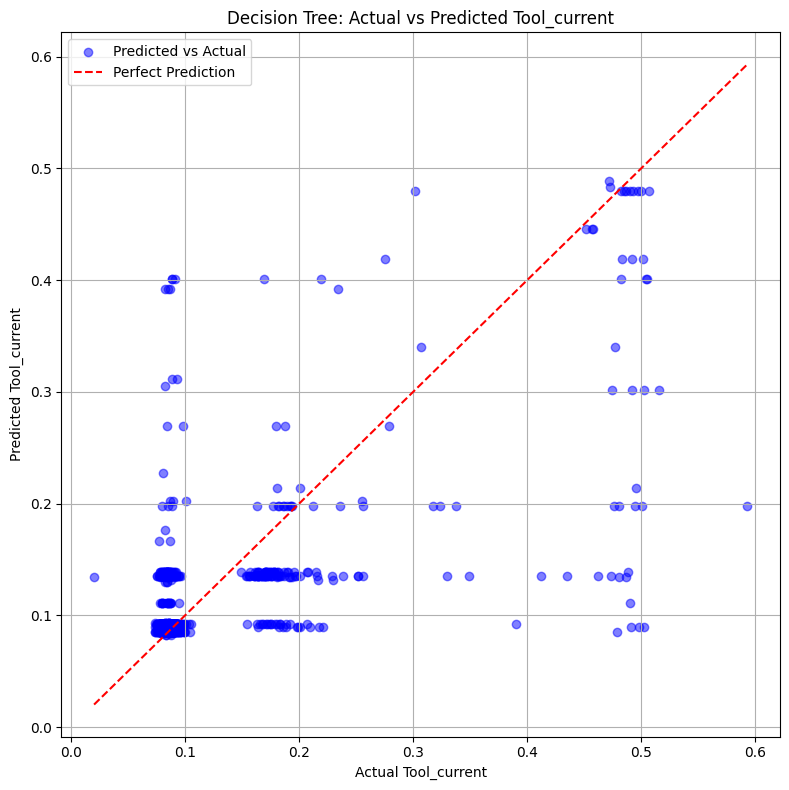

In [118]:
# 선형 회귀와 달리 비선형 관계를 잘 잡았는지 눈으로 확인하는 산점도입니다.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', label='Predicted vs Actual')

# 완벽하게 예측했을 때의 대각선 (y=x)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Decision Tree: Actual vs Predicted Tool_current')
plt.xlabel('Actual Tool_current')
plt.ylabel('Predicted Tool_current')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Random Forest

### Cell 1: 라이브러리 및 데이터 로드

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 입력 피처(X) 및 타겟(y) 설정
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'
]
X = df_clean[input_cols]
y = df_clean['Tool_current']

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개, 타겟: Tool_current")

데이터 크기: (7355, 24)
피처 개수: 12개, 타겟: Tool_current


### Cell 2: Train/Test Split

In [55]:
# 1. 80:20으로 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest 역시 Decision Tree의 앙상블이므로 
# 거리 계산을 하지 않아 스케일링(StandardScaler 등)이 필요하지 않습니다.

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (5884, 12)
테스트 데이터 크기: (1471, 12)


### Cell 3: Random Forest K-Fold 교차검증 및 다각도 하이퍼파라미터 튜닝

In [56]:
# 1. 교차 검증 (K-Fold) 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Random Forest Regressor 기본 모델 생성
rf_reg = RandomForestRegressor(random_state=42)

# 3. 다양하게 설정된 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [50, 100, 200],         # 트리의 개수
    'max_depth': [None, 10, 20, 30],        # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],        # 노드 분할을 위한 최소 샘플 수
}

# 4. GridSearchCV 실행 (R² 기준으로 최적 파라미터 탐색)
print("--- Random Forest 하이퍼파라미터 대규모 탐색 중 (시간이 소요됩니다) ---")
grid_search_rf = GridSearchCV(
    estimator=rf_reg, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    #n_jobs=-1,  # 모든 CPU 코어 사용
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

# 5. 최적 모델 추출
best_rf = grid_search_rf.best_estimator_

print("\n[GridSearchCV 탐색 완료]")
print(f"최적의 하이퍼파라미터: {grid_search_rf.best_params_}")
print(f"최고 교차 검증 R² 점수: {grid_search_rf.best_score_:.4f}")

--- Random Forest 하이퍼파라미터 대규모 탐색 중 (시간이 소요됩니다) ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

### Cell 4: 하이퍼파라미터 조합별 R² 순위 확인 (Top 10)

In [ ]:
# 1. GridSearchCV의 cv_results_에서 데이터 추출하여 DataFrame 생성
cv_results = pd.DataFrame(grid_search_rf.cv_results_)

# 2. 필요한 컬럼만 선택 (파라미터들, 평균 교차검증 점수)
# scoring='r2'로 설정했으므로 mean_test_score가 CV 평균 R² 점수입니다.
columns_to_keep = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results = cv_results[columns_to_keep]

# 3. 컬럼명 직관적으로 변경
cv_results.rename(columns={
    'mean_test_score': 'CV Mean R²',
    'std_test_score': 'R² Std. Dev',
    'rank_test_score': 'Rank'
}, inplace=True)

# 4. R² 점수 기준 내림차순 정렬
cv_results_sorted = cv_results.sort_values(by='CV Mean R²', ascending=False).reset_index(drop=True)

# 5. 파라미터 딕셔너리를 보기 좋게 풀어서 컬럼으로 만들기
params_df = pd.json_normalize(cv_results_sorted['params'])
cv_results_final = pd.concat([params_df, cv_results_sorted.drop(columns=['params'])], axis=1)

# 순위(Rank)를 인덱스로 설정
cv_results_final.index = np.arange(1, len(cv_results_final) + 1)
cv_results_final.index.name = "Rank"

print("\n--- [GridSearchCV 결과] R² 기준 상위 10개 하이퍼파라미터 조합 ---")
display(cv_results_final.head(10).style.format({
    "CV Mean R²": "{:.4f}",
    "R² Std. Dev": "{:.4f}"
}))


--- [GridSearchCV 결과] R² 기준 상위 10개 하이퍼파라미터 조합 ---


,max_depth,min_samples_split,n_estimators,CV Mean R²,R² Std. Dev,Rank
Rank,,,,,,
1,20.000000,2,200,0.5776,0.0576,1
2,20.000000,2,100,0.5771,0.0616,2
3,nan,5,200,0.5770,0.0584,3
4,20.000000,5,200,0.5768,0.0572,4
5,30.000000,5,200,0.5764,0.0581,5
6,30.000000,5,100,0.5762,0.0618,6
7,30.000000,2,200,0.5762,0.0574,7
8,nan,5,100,0.5761,0.0618,8
9,20.000000,5,100,0.5752,0.0607,9


### Cell 5: 최적의 Random Forest 모델로 최종 테스트 평가

In [ ]:
# 1. 1등을 차지한 최적 모델로 Train/Test 예측
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# 2. 평가지표 계산 함수
def print_metrics_rf(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print("--- [최종 결과] Random Forest Regressor (Tuned) ---")
print_metrics_rf(y_train, y_train_pred_rf, "Train")
print_metrics_rf(y_test, y_test_pred_rf, "Test")

# R² 점수가 Train과 Test에서 어떻게 차이나는지(과적합 정도) 확인하세요.

--- [최종 결과] Random Forest Regressor (Tuned) ---

[Train 데이터 평가]
R² (결정계수) : 0.9424
MSE  : 0.000368
RMSE : 0.019185
MAE  : 0.007779

[Test 데이터 평가]
R² (결정계수) : 0.5303
MSE  : 0.002579
RMSE : 0.050788
MAE  : 0.018921


### Cell 6: 피처 중요도 (Feature Importance) 시각화

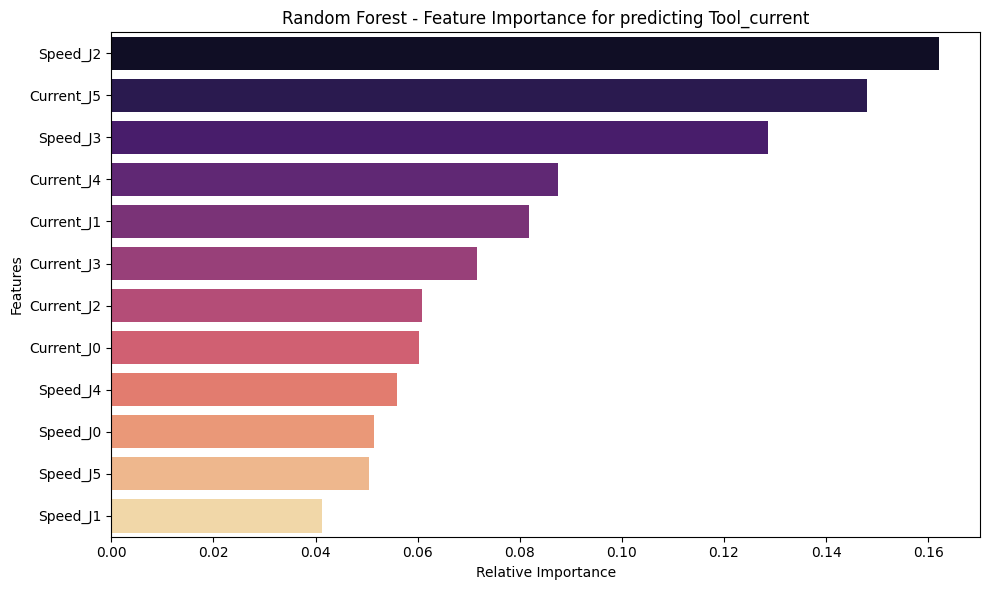

가장 중요한 피처 상위 3개:
   Feature  Importance
  Speed_J2    0.162057
Current_J5    0.148008
  Speed_J3    0.128613


In [ ]:
# 1. Random Forest의 Feature Importance 추출
feature_importances_rf = best_rf.feature_importances_
importance_df_rf = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances_rf
}).sort_values(by='Importance', ascending=False)

# 2. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='magma')
plt.title('Random Forest - Feature Importance for predicting Tool_current')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 가장 중요한 상위 3개 피처 출력
print("가장 중요한 피처 상위 3개:")
print(importance_df_rf.head(3).to_string(index=False))

### Cell 7: 실제값 vs 예측값 산점도

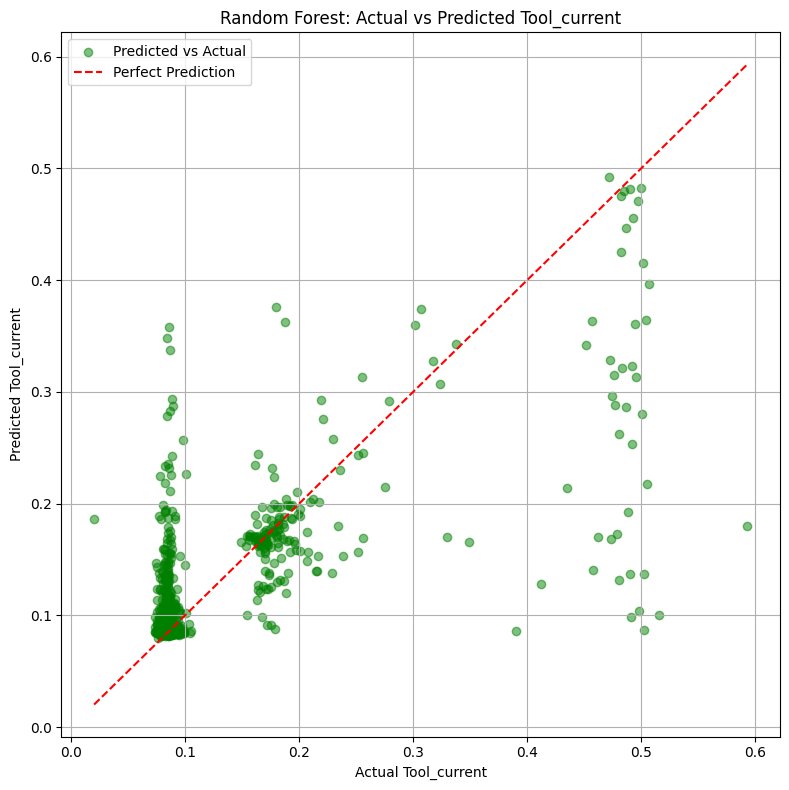

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, color='green', label='Predicted vs Actual')

# 완벽하게 예측했을 때의 대각선 (y=x)
min_val = min(y_test.min(), y_test_pred_rf.min())
max_val = max(y_test.max(), y_test_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted Tool_current')
plt.xlabel('Actual Tool_current')
plt.ylabel('Predicted Tool_current')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()